In [1]:
from logicqubit.logic import *
from openfermion.chem import MolecularData
from openfermion.transforms import get_fermion_operator, jordan_wigner, bravyi_kitaev, parity_code
from openfermion.linalg import get_ground_state, get_sparse_operator
from openfermionpyscf import run_pyscf
from cmath import *
import numpy as np
import scipy
from scipy.optimize import *
import matplotlib.pyplot as plt

logicqubit version 1.7.9


Second Quantized Hamiltonian
\begin{eqnarray*}
    \mathcal{H}(r)=h_0 + \sum_{pq} h_{pq}(r) a^{\dagger}_p a_q +\frac{1}{2} \sum_{pqrs} h_{pqrs}(r) a^{\dagger}_p a^{\dagger}_qa_ra_s
\end{eqnarray*}

\begin{eqnarray*}
    h_{pq}(r)=\int{d\mathbf{r}}\,\phi^*_p(\mathbf{r})\left(-\frac{1}{2}\nabla^2-\sum_{a}{\frac{Z_a}{\mathbf{r}_{a,\mathbf{r}}}}\right)\phi_q(\mathbf{r})
\end{eqnarray*}

\begin{eqnarray*}
    h_{pqrs}(r)=\int{d\mathbf{r_1}\,d\mathbf{r_2}}\,\phi^*_p(\mathbf{r_1})\phi^*_q(\mathbf{r_2})r_{1,2}^{-1}\phi_r(\mathbf{r_1})\phi_s(\mathbf{r_2})
\end{eqnarray*}

Jordan-Wigner transformation
\begin{eqnarray*}
    a^{\dagger} = I^{\otimes j-1}\otimes \sigma_{-} \otimes \sigma_{z}^{\otimes N-j}\\
    a = I^{\otimes j-1}\otimes \sigma_{+} \otimes \sigma_{z}^{\otimes N-j}
\end{eqnarray*}

In [2]:
gates = Gates(1)

ID = gates.ID()
X = gates.X()
Y = gates.Y()
Z = gates.Z()

Repulsion energy (Eh): 0.7055696793059831
step = 01 | distance = 0.3000 | exact = -0.6018 | logicqubit = -0.6018 | l_error = 1.71e-07 | qiskit = -0.6018 | q_error = 1.71e-07
step = 02 | distance = 0.3564 | exact = -0.8082 | logicqubit = -0.8082 | l_error = 2.20e-07 | qiskit = -0.8082 | q_error = 2.20e-07
step = 03 | distance = 0.4128 | exact = -0.9390 | logicqubit = -0.9390 | l_error = 2.28e-07 | qiskit = -0.9390 | q_error = 2.28e-07
step = 04 | distance = 0.4692 | exact = -1.0230 | logicqubit = -1.0230 | l_error = 2.66e-07 | qiskit = -1.0230 | q_error = 2.66e-07
step = 05 | distance = 0.5256 | exact = -1.0764 | logicqubit = -1.0764 | l_error = 2.58e-07 | qiskit = -1.0764 | q_error = 2.58e-07
step = 06 | distance = 0.5821 | exact = -1.1091 | logicqubit = -1.1091 | l_error = 3.50e-07 | qiskit = -1.1091 | q_error = 3.50e-07
step = 07 | distance = 0.6385 | exact = -1.1275 | logicqubit = -1.1275 | l_error = 3.95e-07 | qiskit = -1.1275 | q_error = 3.95e-07
step = 08 | distance = 0.6949 | ex

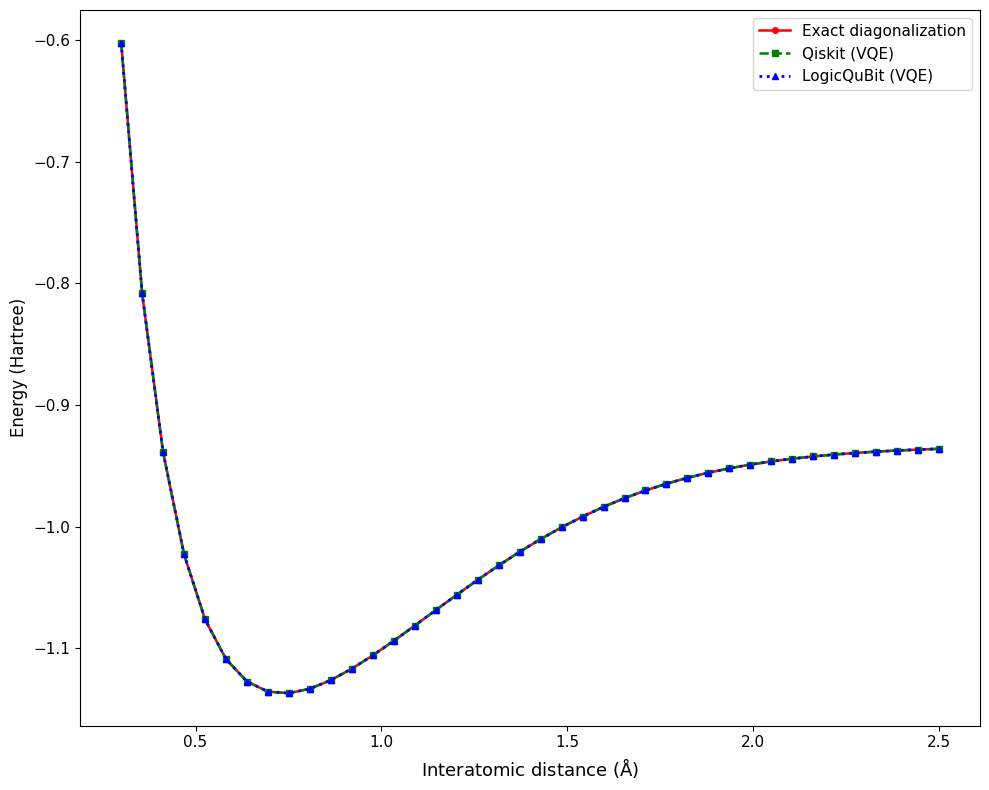

In [14]:
import numpy as np
import scipy
import matplotlib.pyplot as plt

from scipy.optimize import minimize
from qiskit import QuantumCircuit
from qiskit.quantum_info import Statevector

def get_molecule(distance = 0.75):
    geometry = [('H', (0., 0., 0.)), ('H', (0., 0., distance))]
    basis = "sto-3g"
    multiplicity = 1
    charge = 0
    description = "H2"

    molecule_h2 = MolecularData(geometry, basis, multiplicity, charge, description)
    molecule_h2 = run_pyscf(molecule_h2, run_scf=1, verbose=0)

    molecule_h2 = jordan_wigner(get_fermion_operator(molecule_h2.get_molecular_hamiltonian()))

    mol_gates = list(molecule_h2.terms.keys())
    mol_co = list(molecule_h2.terms.values())
    return mol_gates, mol_co

def get_sigma(gate_name):
    if gate_name == 'X':
        gate = X
    elif gate_name == 'Y':
        gate = Y
    elif gate_name == 'Z':
        gate = Z
    else:
        gate = ID
    return gate

def get_H_k(mol_gates):
    gate_list = []
    name_list = []
    for pauli_gate in mol_gates:
        prod_list = [get_sigma('I') for _ in range(4)]
        name_gate_list = ['I' for _ in range(4)]
        for term in pauli_gate:
            prod_list[3-term[0]] = get_sigma(term[1])
            name_gate_list[3-term[0]] = term[1]
        gate_kron = prod_list[0]
        for item in prod_list[1:]:
            gate_kron = gate_kron.kron(item)
        gate_list.append(gate_kron)
        name_list.append(name_gate_list)
    return gate_list, name_list

def get_base(mol_gate):
    prod_list = [Matrix([1, 1]) for _ in range(4)]
    if isinstance(mol_gate, tuple):
        for item in mol_gate:
            prod_list[3-item[0]] = Matrix([1, -1])
    else:
        gate_list = list(mol_gate)
        for i, item in enumerate(gate_list):
            if item != 'I':
                prod_list[i] = Matrix([1, -1])
    base_kron = prod_list[0]
    for item in prod_list[1:]:
        base_kron = base_kron.kron(item)
    return base_kron

def sum(items):
    value = items[0]
    for item in items[1:]:
        value = value + item
    return value

def repulsion_energy(Z1=1, Z2=1, r=75e-12):
    Eh = 4.3597447222071e-18
    ep0 = 8.854187e-12
    e = -1.602176634e-19
    return (1/(4*pi*ep0)*(Z1*Z2*e**2)/r)/Eh

rep_energy = repulsion_energy()
print("Repulsion energy (Eh): %s" % rep_energy)

def expectation_value(measurements, base=np.array([ 1, -1, -1,  1, -1,  1,  1, -1,
                                                   -1,  1,  1, -1,  1, -1, -1,  1])):
    probabilities = np.array(measurements)
    expectation = np.sum(base * probabilities)
    return expectation.real

def pauli_name(pauli_gate):
    name = ['I'] * 4
    for qubit, op in pauli_gate:
        name[3-qubit] = op
    return ''.join(name)

def ansatz_4q4(q1, q2, q3, q4, params):
    q1.RY(params[0])
    q2.RZ(params[1])
    q3.RY(params[2])
    q4.RZ(params[3])
    q2.CNOT(q1)
    q3.CNOT(q2)
    q4.CNOT(q3)

def ansatz_4q4_qiskit(qc, params):
    qc.ry(params[0], 0)
    qc.rz(params[1], 1)
    qc.ry(params[2], 2)
    qc.rz(params[3], 3)
    qc.cx(0, 1)
    qc.cx(1, 2)
    qc.cx(2, 3)

def qiskit_probabilities(qc):
    sv = Statevector.from_instruction(qc)
    return np.array(sv.probabilities(), dtype=float)

# LogicQuBit
def sigma_zzzz(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    result = logicQuBit.Measure([q1, q2, q3, q4])

    iiiz = expectation_value(result, get_base('IIIZ').get())
    iizi = expectation_value(result, get_base('IIZI').get())
    izii = expectation_value(result, get_base('IZII').get())
    ziii = expectation_value(result, get_base('ZIII').get())
    iizz = expectation_value(result, get_base('IIZZ').get())

    iziz = expectation_value(result, get_base('IZIZ').get())
    ziiz = expectation_value(result, get_base('ZIIZ').get())
    izzi = expectation_value(result, get_base('IZZI').get())
    zizi = expectation_value(result, get_base('ZIZI').get())
    zzii = expectation_value(result, get_base('ZZII').get())

    return iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii

def sigma_yxxy(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    q2.RY(-pi/2)
    q3.RY(-pi/2)

    q1.RX(pi/2)
    q4.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def sigma_xyyx(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    q1.RY(-pi/2)
    q4.RY(-pi/2)

    q2.RX(pi/2)
    q3.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def sigma_xxyy(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    q1.RY(-pi/2)
    q2.RY(-pi/2)

    q3.RX(pi/2)
    q4.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def sigma_yyxx(params):
    logicQuBit = LogicQuBit(4, first_left=False)
    q1 = Qubit()
    q2 = Qubit()
    q3 = Qubit()
    q4 = Qubit()

    ansatz_4q4(q1, q2, q3, q4, params)

    q3.RY(-pi/2)
    q4.RY(-pi/2)

    q1.RX(pi/2)
    q2.RX(pi/2)

    result = logicQuBit.Measure([q1, q2, q3, q4])
    result = expectation_value(result)
    return result

def expectation_energy(params, co_dict):
    iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii = sigma_zzzz(params)
    yxxy = sigma_yxxy(params)
    xyyx = sigma_xyyx(params)
    xxyy = sigma_xxyy(params)
    yyxx = sigma_yyxx(params)

    result = (
        co_dict.get('IIII', 0.0)
        + co_dict.get('IIIZ', 0.0) * iiiz
        + co_dict.get('IIZI', 0.0) * iizi
        + co_dict.get('IZII', 0.0) * izii
        + co_dict.get('ZIII', 0.0) * ziii
        + co_dict.get('IIZZ', 0.0) * iizz
        + co_dict.get('YXXY', 0.0) * yxxy
        + co_dict.get('XYYX', 0.0) * xyyx
        + co_dict.get('XXYY', 0.0) * xxyy
        + co_dict.get('YYXX', 0.0) * yyxx
        + co_dict.get('IZIZ', 0.0) * iziz
        + co_dict.get('ZIIZ', 0.0) * ziiz
        + co_dict.get('IZZI', 0.0) * izzi
        + co_dict.get('ZIZI', 0.0) * zizi
        + co_dict.get('ZZII', 0.0) * zzii
    )
    return result


# Qiskit
def sigma_zzzz_qiskit(params):
    qc = QuantumCircuit(4)
    ansatz_4q4_qiskit(qc, params)

    result = qiskit_probabilities(qc)

    iiiz = expectation_value(result, get_base('IIIZ').get())
    iizi = expectation_value(result, get_base('IIZI').get())
    izii = expectation_value(result, get_base('IZII').get())
    ziii = expectation_value(result, get_base('ZIII').get())
    iizz = expectation_value(result, get_base('IIZZ').get())

    iziz = expectation_value(result, get_base('IZIZ').get())
    ziiz = expectation_value(result, get_base('ZIIZ').get())
    izzi = expectation_value(result, get_base('IZZI').get())
    zizi = expectation_value(result, get_base('ZIZI').get())
    zzii = expectation_value(result, get_base('ZZII').get())

    return iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii

def sigma_yxxy_qiskit(params):
    qc = QuantumCircuit(4)
    ansatz_4q4_qiskit(qc, params)

    # medidas em X
    qc.ry(-pi/2, 1)
    qc.ry(-pi/2, 2)

    # medidas em Y
    qc.rx(pi/2, 0)
    qc.rx(pi/2, 3)

    result = qiskit_probabilities(qc)
    result = expectation_value(result)
    return result

def sigma_xyyx_qiskit(params):
    qc = QuantumCircuit(4)
    ansatz_4q4_qiskit(qc, params)

    # medidas em X
    qc.ry(-pi/2, 0)
    qc.ry(-pi/2, 3)

    # medidas em Y
    qc.rx(pi/2, 1)
    qc.rx(pi/2, 2)

    result = qiskit_probabilities(qc)
    result = expectation_value(result)
    return result

def sigma_xxyy_qiskit(params):
    qc = QuantumCircuit(4)
    ansatz_4q4_qiskit(qc, params)

    # medidas em X
    qc.ry(-pi/2, 0)
    qc.ry(-pi/2, 1)

    # medidas em Y
    qc.rx(pi/2, 2)
    qc.rx(pi/2, 3)

    result = qiskit_probabilities(qc)
    result = expectation_value(result)
    return result

def sigma_yyxx_qiskit(params):
    qc = QuantumCircuit(4)
    ansatz_4q4_qiskit(qc, params)

    # medidas em X
    qc.ry(-pi/2, 2)
    qc.ry(-pi/2, 3)

    # medidas em Y
    qc.rx(pi/2, 0)
    qc.rx(pi/2, 1)

    result = qiskit_probabilities(qc)
    result = expectation_value(result)
    return result

def expectation_energy_qiskit(params, co_dict):
    iiiz, iizi, izii, ziii, iizz, iziz, ziiz, izzi, zizi, zzii = sigma_zzzz_qiskit(params)
    yxxy = sigma_yxxy_qiskit(params)
    xyyx = sigma_xyyx_qiskit(params)
    xxyy = sigma_xxyy_qiskit(params)
    yyxx = sigma_yyxx_qiskit(params)

    result = (
        co_dict.get('IIII', 0.0)
        + co_dict.get('IIIZ', 0.0) * iiiz
        + co_dict.get('IIZI', 0.0) * iizi
        + co_dict.get('IZII', 0.0) * izii
        + co_dict.get('ZIII', 0.0) * ziii
        + co_dict.get('IIZZ', 0.0) * iizz
        + co_dict.get('YXXY', 0.0) * yxxy
        + co_dict.get('XYYX', 0.0) * xyyx
        + co_dict.get('XXYY', 0.0) * xxyy
        + co_dict.get('YYXX', 0.0) * yyxx
        + co_dict.get('IZIZ', 0.0) * iziz
        + co_dict.get('ZIIZ', 0.0) * ziiz
        + co_dict.get('IZZI', 0.0) * izzi
        + co_dict.get('ZIZI', 0.0) * zizi
        + co_dict.get('ZZII', 0.0) * zzii
    )
    return result

def gradient(params, evaluate, args):
    n_params = params.shape[0]
    shift = np.pi / 2
    gradients = np.zeros(n_params)
    
    for i in range(n_params):
        #parameter shift rule
        shift_vect = np.array([shift if j == i else 0 for j in range(n_params)])
        shift_right = params + shift_vect
        shift_left = params - shift_vect
        
        expectation_right = evaluate(shift_right, args)
        expectation_left = evaluate(shift_left, args)

        gradients[i] = 0.5 * (expectation_right - expectation_left)

    return gradients

def optimize_energy(co, distance, params, lr=0.1, tol=1e-4, max_iter=1000):
    params = np.array(params, dtype=float).copy()
    last_params = np.zeros(4)

    err = 1
    it = 0
    while err > tol and it < max_iter:
        grad = gradient(params, expectation_energy, co)
        params = params - lr * grad

        err = np.linalg.norm(params - last_params)
        last_params = np.array(params)
        it += 1

    energy = expectation_energy(params, co)
    return energy

def optimize_energy_qiskit(co, distance, params, lr=0.1, tol=1e-4, max_iter=1000):
    params = np.array(params, dtype=float).copy()
    last_params = np.zeros(4)

    err = 1
    it = 0
    while err > tol and it < max_iter:
        grad = gradient(params, expectation_energy_qiskit, co)
        params = params - lr * grad

        err = np.linalg.norm(params - last_params)
        last_params = np.array(params)
        it += 1

    energy = expectation_energy_qiskit(params, co)
    return energy

n = 40
distances = np.linspace(0.3, 2.5, n)

exact_energy = []
energies_logicqubit = []
energies_qiskit = []
params_init = np.random.uniform(-np.pi, np.pi, 4)

for i, distance in enumerate(distances):

    mol_gates, mol_co = get_molecule(distance)
    co_dict = {pauli_name(g): c.real for g, c in zip(mol_gates, mol_co)}

    H = sum([gate * coef for gate, coef in zip(get_H_k(mol_gates)[0], mol_co)])
    exact_e = scipy.linalg.eigvalsh(H.get())[0].real
    exact_energy.append(exact_e)

    energy_logic = optimize_energy(co_dict, distance, params_init)
    energy_qiskit = optimize_energy_qiskit(co_dict, distance, params_init)

    energies_logicqubit.append(energy_logic)
    energies_qiskit.append(energy_qiskit)

    print(
        f"step = {i+1:02d} | "
        f"distance = {distance:.4f} | "
        f"exact = {exact_e:.4f} | "
        f"logicqubit = {energy_logic:.4f} | l_error = {abs(energy_logic - exact_e):.2e} | "
        f"qiskit = {energy_qiskit:.4f} | q_error = {abs(energy_qiskit - exact_e):.2e}"
    )

fig, ax = plt.subplots(1, 1, figsize=(10, 8))

ax.plot(distances, exact_energy, color='red', linestyle='-', marker='o', markersize=4, linewidth=1.8, label='Exact diagonalization')
ax.plot(distances, energies_qiskit, color='green', linestyle='--', marker='s', markersize=4, linewidth=1.8, label='Qiskit (VQE)')
ax.plot(distances, energies_logicqubit, color='blue', linestyle=':', marker='^', markersize=4, linewidth=2.0, label='LogicQuBit (VQE)')

ax.set_xlabel(r'Interatomic distance ($\mathrm{\AA}$)', fontsize=13)
ax.set_ylabel('Energy (Hartree)', fontsize=12)
#ax.set_title(r'$H_2$ dissociation curve', fontsize=13)

ax.legend(fontsize=11, frameon=True)
ax.tick_params(axis='both', labelsize=11)
plt.tight_layout()
plt.savefig("h2_dissociation_curve.png", dpi=300, bbox_inches="tight")
plt.show()